# HealthConnect Clinic Experience Lab
## Week 6: Advanced Analytics, Validation & Decision Support

**Track:** Data Analytics  
**Project:** Improving Patient Appointment Attendance and Healthcare Support Using Data and AI  
**Programme:** AnalystLab Africa Experience Lab  
**Version:** 1.0

---

This notebook continues directly from the Week 5 Data Preparation & Exploratory Data Analysis
notebook. It does **not** repeat the Week 5 cleaning process or the Week 5 exploratory analysis.
It begins from the cleaned dataset produced in Week 5 (`HealthConnect_Week5_Cleaned_Dataset.csv`)
and moves the analytical work into **validation, deeper investigation and decision support**.

## 1. Week 5 → Week 6 Transition

**1.1 Main Week 5 output**  
*HealthConnect Week 5 Data Preparation & Exploratory Data Analysis notebook*, together with the
cleaned analytical dataset (`HealthConnect_Week5_Cleaned_Dataset.csv`, 5,000 records × 18 variables),
four KPIs, a set of exploratory visualisations and six business insights.

**1.2 Most important result produced**  
An overall no-show rate of **48.46%**, with the strongest observed pattern being the increase in
no-show rate as booking lead time increased (27.81% for appointments booked 0–7 days ahead rising
to 60.49% for appointments booked 31–60 days ahead).

**1.3 Main issue or limitation discovered**  
Week 5 reported group differences as raw percentages only. No test of statistical significance,
no confidence intervals and no group-size weighting were applied. Three specific consequences were
flagged at the end of Week 5:

1. Some reported differences rested on very small groups (for example a 100% no-show rate for
   patients with five previous no-shows).
2. Every relationship was examined one variable at a time, so it was not known whether the weaker
   patterns (appointment type, reminder channel, waiting time) were independent effects or simply
   noise.
3. No cross-track exchange took place in Week 5, so the analytical findings had not yet been
   converted into a form another track could use.

**1.4 Track(s) relevant to Week 6 activities**  
**Data Science track** — the analytical findings are intended to inform feature selection,
target definition and validation design for the no-show prediction model.

**1.5 What Week 6 improves, integrates and validates**

| Week 5 position | Week 6 action |
|---|---|
| Six insights stated as raw percentage differences | Test each one for statistical significance, effect size and confidence interval |
| One-variable-at-a-time analysis | Multivariate (adjusted) analysis to separate real drivers from noise |
| Four descriptive KPIs | Validate, correct and extend into a decision-relevant KPI set |
| Dependency on the Data Science track identified but unused | Produce and hand over a modelling feature specification and a validated risk-tier cohort |
| Static exploratory charts | Rebuild as a single decision-support view driven by the validated findings |

## 2. Part 1 — Week 6 Integration Readiness

**A. Integration point**

| Item | Detail |
|---|---|
| Track worked with | Data Science track (no-show prediction model) |
| Output needed from that track | Week 5 baseline model definition: target encoding, candidate feature list, validation split method, and the baseline performance figures the model must be improved against |
| Output provided to that track | (i) Statistically validated driver list with adjusted effect sizes, (ii) a modelling feature specification file, (iii) a validation-design warning on patient-level record repetition, (iv) a labelled risk-tier cohort file for benchmarking |
| Why the connection is relevant | The Data Science track's Week 6 task is feature refinement and error analysis. Feature decisions taken without evidence of which variables carry real signal are the most likely source of avoidable model error; the Data Analytics track holds that evidence |

**B. Integration objective**

> After this integration activity, the Data Science track's feature set should be selected on tested
> evidence rather than on Week 5 raw percentage differences, and its validation split should account
> for the repeated-patient structure of the dataset that this analysis identified.

**C. Evidence produced**

1. `HealthConnect_Week6_Feature_Specification.csv` — per-variable evidence and modelling recommendation
2. `HealthConnect_Week6_Validated_Findings.csv` — statistical test results for every Week 5 claim
3. `HealthConnect_Week6_Refined_KPIs.csv` — corrected and extended KPI definitions
4. `HealthConnect_Week6_Risk_Tier_Cohort.csv` — rule-based risk tier assigned to all 5,000 appointments
5. `HealthConnect_Week6_Integration_Record.docx` — the coordination record and the exchange log
6. `HealthConnect_Week6_Issue_Log.csv` — issues raised, resolved and outstanding

Full documentation of the exchange is in Section 12 of this notebook and in the integration record.

In [1]:
# Week 6 environment
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import statsmodels.formula.api as smf

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "font.size": 9,
})

INK = "#1f3a5f"
ACCENT = "#c44536"
MUTED = "#9aa5b1"
OK = "#2a7f62"

print("Week 6 analytical environment ready")

Week 6 analytical environment ready


In [2]:
# Load the Week 5 cleaned dataset. The original raw resource is not modified at any point.
df = pd.read_csv(
    "HealthConnect_Week5_Cleaned_Dataset.csv",
    parse_dates=["booking_date", "appointment_date"],
)

# Binary analytical target used throughout Week 6
df["is_noshow"] = (df["appointment_outcome"] == "No-Show").astype(int)

print("Records:", len(df), "| Variables:", df.shape[1])
print("Appointment window:", df["appointment_date"].min().date(), "→", df["appointment_date"].max().date())
df["appointment_outcome"].value_counts()

Records: 5000 | Variables: 19
Appointment window: 2025-01-01 → 2026-06-30


appointment_outcome
No-Show      2423
Attended     2314
Cancelled     263
Name: count, dtype: int64

In [3]:
# Analytical bands reused from Week 5 so that Week 6 results remain directly comparable
df["lead_band"] = pd.cut(df["booking_lead_days"], [-1, 7, 14, 30, 60],
                         labels=["0-7 days", "8-14 days", "15-30 days", "31-60 days"])
df["dist_band"] = pd.cut(df["distance_to_clinic_km"], [0, 5, 10, 20, 30, 45],
                         labels=["0-5 km", "5-10 km", "10-20 km", "20-30 km", "30-45 km"])
df["wait_band"] = pd.cut(df["waiting_time_minutes"], [0, 15, 30, 45, 60, 75],
                         labels=["0-15 min", "16-30 min", "31-45 min", "46-60 min", "61-75 min"])
df["prev_ns_band"] = pd.cut(df["previous_no_shows"], [-1, 0, 1, 10],
                            labels=["0 previous", "1 previous", "2+ previous"])

df[["lead_band", "prev_ns_band"]].head()

,lead_band,prev_ns_band
0,8-14 days,0 previous
1,0-7 days,0 previous
2,31-60 days,1 previous
3,31-60 days,1 previous
4,31-60 days,1 previous


## 3. Data Integrity Re-Validation

Week 5 validated ranges, types, duplicates and missing values. Week 6 re-examines the dataset for
**structural properties that affect analysis and modelling** rather than for formatting errors.
Four checks were carried out.

In [4]:
# Check 1 — internal consistency of the derived booking lead time
recomputed = (df["appointment_date"] - df["booking_date"]).dt.days
print("Check 1 — booking_lead_days vs (appointment_date - booking_date)")
print("  Mismatched records:", int((recomputed != df["booking_lead_days"]).sum()))
print("  Lead time range:", df["booking_lead_days"].min(), "to", df["booking_lead_days"].max(), "days")

# Check 2 — reminder_channel missingness is structural, not a data fault
print("\nCheck 2 — reminder_channel by reminder_sent")
print(pd.crosstab(df["reminder_sent"], df["reminder_channel"].fillna("(not sent)")))

# Check 3 — is previous_no_shows ever greater than previous_appointments?
print("\nCheck 3 — logically impossible history values:",
      int((df["previous_no_shows"] > df["previous_appointments"]).sum()))

Check 1 — booking_lead_days vs (appointment_date - booking_date)
  Mismatched records: 0
  Lead time range: 0 to 60 days

Check 2 — reminder_channel by reminder_sent
reminder_channel  (not sent)  Email   SMS  WhatsApp
reminder_sent                                      
No                      1366      0     0         0
Yes                        0    533  2000      1101

Check 3 — logically impossible history values: 0


In [5]:
# Check 4 — record independence. Week 5 treated every row as an independent appointment.
appts_per_patient = df["patient_id"].value_counts()

print("Check 4 — record independence")
print("  Unique patients:", df["patient_id"].nunique())
print("  Appointments:   ", len(df))
print("  Mean appointments per patient: %.2f" % appts_per_patient.mean())
print("  Maximum appointments for one patient:", appts_per_patient.max())
print("  Share of appointments belonging to patients with more than one appointment: %.1f%%"
      % (100 * df["patient_id"].map(appts_per_patient).gt(1).mean()))

Check 4 — record independence
  Unique patients: 1696
  Appointments:    5000
  Mean appointments per patient: 2.95
  Maximum appointments for one patient: 9
  Share of appointments belonging to patients with more than one appointment: 94.0%


In [6]:
# Check 5 — waiting_time_minutes is populated for appointments that were never attended
wait_by_outcome = df.groupby("appointment_outcome")["waiting_time_minutes"].agg(
    recorded="count", missing=lambda s: s.isna().sum(), mean="mean", median="median"
).round(2)

print("Check 5 — waiting_time_minutes by appointment outcome")
print(wait_by_outcome)

Check 5 — waiting_time_minutes by appointment outcome
                     recorded  missing   mean  median
appointment_outcome                                  
Attended                 2293       21  24.29    24.0
Cancelled                 261        2  23.21    22.0
No-Show                  2386       37  24.20    24.0


### 3.1 Integrity findings

| # | Check | Result | Consequence for Week 6 |
|---|---|---|---|
| 1 | Booking lead time consistency | 0 mismatches across 5,000 records; range 0–60 days | `booking_lead_days` is safe to use as a continuous variable |
| 2 | Reminder channel missingness | All 1,366 missing values occur where `reminder_sent = "No"` | Confirms the Week 5 decision not to impute; the field must be modelled as "not applicable", never as "unknown" |
| 3 | Appointment history logic | 0 records where previous no-shows exceed previous appointments | History fields are internally coherent |
| 4 | **Record independence** | 5,000 appointments belong to only **1,696 patients**; 94.0% of appointments belong to a patient who appears more than once | **Week 5 treated rows as independent. They are not.** This affects both the interpretation of patient-level findings and, critically, how the Data Science track must split train and test data |
| 5 | **Waiting time for non-attended appointments** | `waiting_time_minutes` is recorded for 2,386 of 2,423 no-shows, with a mean (24.20 min) statistically indistinguishable from attended appointments (24.29 min) | A patient who did not attend cannot have accrued a clinic waiting time. The field cannot mean what Week 5 assumed it meant, and the Week 5 waiting-time analysis is not interpretable as stated |

Findings 4 and 5 are both new in Week 6 and both were passed to the Data Science track
(Section 12). Finding 4 is the single most consequential item this week: if the modelling track
splits train and test data randomly, the same patient's appointments appear on both sides of the
split and the reported model performance will be optimistic.

## 4. Statistical Validation of the Week 5 Findings

Week 5 reported group differences as raw percentages. Week 6 subjects each reported relationship
to a chi-square test of independence and reports **Cramér's V** as the effect size, so that
statistical significance and practical magnitude are separated. Cramér's V is interpreted here on
the conventional scale: below 0.10 negligible, 0.10–0.20 weak, 0.20–0.30 moderate, above 0.30 strong.

In [7]:
def cramers_v(contingency):
    chi2 = stats.chi2_contingency(contingency)[0]
    n = contingency.values.sum()
    r, k = contingency.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))


def validate(variable, label):
    sub = df[[variable, "is_noshow"]].dropna()
    ct = pd.crosstab(sub[variable], sub["is_noshow"])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    v = cramers_v(ct)
    if v < 0.10:
        strength = "Negligible"
    elif v < 0.20:
        strength = "Weak"
    elif v < 0.30:
        strength = "Moderate"
    else:
        strength = "Strong"
    return {
        "Variable": label, "n": int(ct.values.sum()), "Chi-square": round(chi2, 2),
        "df": dof, "p-value": p, "Cramers V": round(v, 3), "Effect size": strength,
        "Significant (a=0.05)": "Yes" if p < 0.05 else "No",
    }


tests = [
    ("lead_band", "Booking lead time"),
    ("prev_ns_band", "Previous no-show history"),
    ("dist_band", "Distance to clinic"),
    ("appointment_type", "Appointment type"),
    ("reminder_sent", "Reminder sent"),
    ("reminder_channel", "Reminder channel"),
    ("age_group", "Age group"),
    ("appointment_day", "Appointment day"),
    ("appointment_time", "Appointment time"),
    ("gender", "Gender"),
    ("wait_band", "Waiting time"),
]

validation = pd.DataFrame([validate(v, l) for v, l in tests]).sort_values("Cramers V", ascending=False)
validation["p-value"] = validation["p-value"].apply(lambda p: "<0.001" if p < 0.001 else f"{p:.4f}")
validation.reset_index(drop=True)

,Variable,n,Chi-square,df,p-value,Cramers V,Effect size,Significant (a=0.05)
0,Booking lead time,5000,318.12,3,<0.001,0.252,Moderate,Yes
1,Previous no-show history,5000,77.82,2,<0.001,0.125,Weak,Yes
2,Distance to clinic,4910,22.41,4,<0.001,0.068,Negligible,Yes
3,Age group,5000,9.51,5,0.0905,0.044,Negligible,No
4,Appointment type,5000,7.89,3,0.0484,0.040,Negligible,Yes
5,Reminder channel,3634,4.88,2,0.0870,0.037,Negligible,No
6,Reminder sent,5000,6.30,1,0.0120,0.036,Negligible,Yes
7,Appointment day,5000,4.48,6,0.6120,0.030,Negligible,No
8,Waiting time,4940,2.22,4,0.6962,0.021,Negligible,No
9,Gender,5000,1.12,2,0.5721,0.015,Negligible,No


### 4.1 What the validation shows

Only **two** of the relationships explored in Week 5 carry a non-negligible effect size:
booking lead time (V = 0.252, moderate) and previous no-show history (V = 0.125, weak).

Distance to clinic, appointment type and reminder status are statistically significant but have
**negligible** effect sizes (V ≤ 0.068) — they are real but small. Reminder channel, age group,
appointment day, appointment time, gender and waiting time show **no** statistically significant
association at all.

This is the central analytical correction of Week 6: Week 5 presented six insights as though they
were of comparable weight. They are not.

In [8]:
# 95% confidence intervals (Wilson score interval) for every group rate reported in Week 5.
def wilson(k, n, z=1.96):
    if n == 0:
        return np.nan, np.nan
    p = k / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return 100 * (centre - half), 100 * (centre + half)


def rate_table(group, label=None):
    rows = []
    for level, s in df.groupby(group, observed=True)["is_noshow"]:
        n, k = len(s), int(s.sum())
        lo, hi = wilson(k, n)
        rows.append({
            "Group": str(level), "n": n, "No-shows": k,
            "Rate %": round(100 * k / n, 2),
            "95% CI low": round(lo, 2), "95% CI high": round(hi, 2),
            "CI width (pp)": round(hi - lo, 1),
        })
    out = pd.DataFrame(rows)
    out.insert(0, "Variable", label or group)
    return out


ci_lead = rate_table("lead_band", "Booking lead time")
ci_prev = rate_table("previous_no_shows", "Previous no-shows")
print(ci_lead.to_string(index=False))
print()
print(ci_prev.to_string(index=False))

         Variable      Group    n  No-shows  Rate %  95% CI low  95% CI high  CI width (pp)
Booking lead time   0-7 days  640       178   27.81       24.48        31.41            6.9
Booking lead time  8-14 days  602       202   33.55       29.90        37.42            7.5
Booking lead time 15-30 days 1333       576   43.21       40.57        45.89            5.3
Booking lead time 31-60 days 2425      1467   60.49       58.53        62.42            3.9

         Variable Group    n  No-shows  Rate %  95% CI low  95% CI high  CI width (pp)
Previous no-shows     0 2921      1271   43.51       41.72        45.32            3.6
Previous no-shows     1 1548       828   53.49       51.00        55.96            5.0
Previous no-shows     2  438       260   59.36       54.70        63.86            9.2
Previous no-shows     3   78        53   67.95       56.96        77.25           20.3
Previous no-shows     4   12         8   66.67       39.06        86.19           47.1
Previous no-shows

### 4.2 Small-group findings that Week 5 could not resolve

Week 5 flagged the 100% no-show rate for patients with five previous no-shows as requiring caution
but could not quantify that caution. The confidence intervals settle it:

- **5 previous no-shows:** n = 3, rate 100%, 95% CI **43.85% – 100%**. The interval spans more than
  half the possible range. This group carries no usable information and is withdrawn from reporting.
- **4 previous no-shows:** n = 12, rate 66.67%, 95% CI **39.06% – 86.19%**. Also unusable on its own.
- **3 previous no-shows:** n = 78, rate 67.95%, 95% CI **56.96% – 77.25%**. Directionally reliable.

**Action taken:** previous no-show history is collapsed to `0 / 1 / 2+` for all Week 6 reporting and
for the feature specification handed to the Data Science track. The 2+ band (n = 531) is stable,
whereas the separate 3, 4 and 5 bands are not.

Similarly, the 30–45 km distance band that Week 5 reported at 68.06% contains only **72 appointments**
with a 95% CI of 56.61% – 77.67%. The direction holds; the specific figure should not be quoted as a
precise operational target.

## 5. Multivariate Analysis — Separating Real Drivers From Noise

Every Week 5 relationship was examined one variable at a time. A one-variable view cannot tell
whether a difference belongs to the variable itself or to something correlated with it. A logistic
regression model is fitted here purely as an **analytical instrument** — it is not the predictive
deliverable, which belongs to the Data Science track — in order to estimate each variable's
association with no-show behaviour **while holding the others constant**.

In [9]:
model_df = df.dropna(subset=["distance_to_clinic_km"]).copy()
model_df["reminder"] = (model_df["reminder_sent"] == "Yes").astype(int)

formula = (
    "is_noshow ~ booking_lead_days + previous_no_shows + previous_appointments "
    "+ distance_to_clinic_km + reminder + age "
    "+ C(appointment_type) + C(appointment_time) + C(gender)"
)

logit = smf.logit(formula, data=model_df).fit(disp=0)

adjusted = pd.DataFrame({
    "Adjusted OR": np.exp(logit.params).round(4),
    "95% CI low": np.exp(logit.conf_int()[0]).round(4),
    "95% CI high": np.exp(logit.conf_int()[1]).round(4),
    "p-value": logit.pvalues.round(4),
})
adjusted["Significant"] = np.where(adjusted["p-value"] < 0.05, "Yes", "No")
adjusted = adjusted.drop(index="Intercept")

print("Records used: %d (90 excluded for missing distance)   McFadden pseudo R-squared: %.4f"
      % (int(logit.nobs), logit.prsquared))
adjusted

Records used: 4910 (90 excluded for missing distance)   McFadden pseudo R-squared: 0.0748


,Adjusted OR,95% CI low,95% CI high,p-value,Significant
C(appointment_type)[T.Follow-up],1.1339,0.9242,1.3913,0.2284,No
C(appointment_type)[T.General Consultation],0.9183,0.7557,1.1159,0.3915,No
C(appointment_type)[T.Specialist Consultation],0.9971,0.7989,1.2445,0.9796,No
C(appointment_time)[T.Evening],1.0843,0.9022,1.3032,0.3882,No
C(appointment_time)[T.Morning],1.0225,0.9004,1.1611,0.7320,No
C(gender)[T.Male],0.9874,0.8762,1.1128,0.8358,No
C(gender)[T.Prefer not to say],0.7426,0.4913,1.1225,0.1580,No
booking_lead_days,1.0347,1.0310,1.0383,0.0000,Yes
previous_no_shows,1.4847,1.3557,1.6260,0.0000,Yes
previous_appointments,0.9850,0.9479,1.0235,0.4399,No


### 5.1 Adjusted results

**Independent drivers (significant after adjustment):**

| Variable | Adjusted odds ratio | Interpretation |
|---|---|---|
| Booking lead time | **1.035 per day** (95% CI 1.031–1.038), p < 0.001 | Each additional day between booking and appointment raises the odds of a no-show by 3.5%. Over a 30-day difference this compounds to roughly **2.8×** the odds |
| Previous no-shows | **1.485 per prior no-show** (95% CI 1.356–1.626), p < 0.001 | Each previous missed appointment raises the odds by about 49% |
| Distance to clinic | **1.022 per km** (95% CI 1.013–1.031), p < 0.001 | Small per kilometre, but a 20 km difference corresponds to roughly 1.5× the odds |
| Reminder sent | **0.830** (95% CI 0.727–0.948), p = 0.006 | Appointments with a reminder have about 17% lower odds of a no-show |

**Variables with no independent association (not significant after adjustment):**
appointment type (all levels p ≥ 0.23), appointment time (p ≥ 0.39), gender (p ≥ 0.16),
age (p = 0.080) and previous appointment count (p = 0.440).

**The reminder finding is the notable change.** In the unadjusted Week 5 view the reminder
difference was marginal (p = 0.012, V = 0.036) and easily dismissed as noise. Once lead time,
history and distance are held constant it strengthens (p = 0.006) and becomes one of only four
independent drivers. Reminder coverage is also the **only one of the four that the clinic directly
controls** — lead time, patient history and distance are given. That single observation changes
where the operational recommendation should point.

**Model explanatory power.** McFadden pseudo R² = 0.075. The measured variables explain only a
small share of no-show behaviour. This is reported plainly to the Data Science track: the available
features are informative but far from sufficient, and no realistic model on this dataset will
approach high accuracy. The practical implication is that the model should be evaluated as a
**ranking tool for prioritising limited outreach capacity**, not as a confident per-patient prediction.

## 6. Segment and Interaction Analysis

Two questions that Week 5 could not answer: do the drivers **compound** when they occur together,
and is the reminder effect **uniform** across the patient base or concentrated in particular segments?

In [10]:
# Compounding: booking lead time against previous no-show history
seg_rate = df.pivot_table(index="prev_ns_band", columns="lead_band",
                          values="is_noshow", aggfunc="mean", observed=True) * 100
seg_n = df.pivot_table(index="prev_ns_band", columns="lead_band",
                       values="is_noshow", aggfunc="size", observed=True)

print("No-show rate (%) by previous no-show history x booking lead time")
print(seg_rate.round(1).to_string())
print("\nGroup sizes")
print(seg_n.to_string())

No-show rate (%) by previous no-show history x booking lead time
lead_band     0-7 days  8-14 days  15-30 days  31-60 days
prev_ns_band                                             
0 previous        21.8       31.6        38.4        55.2
1 previous        33.2       31.8        46.8        66.4
2+ previous       43.6       47.8        57.6        73.0

Group sizes
lead_band     0-7 days  8-14 days  15-30 days  31-60 days
prev_ns_band                                             
0 previous         372        376         763        1410
1 previous         190        157         419         782
2+ previous         78         69         151         233


In [11]:
# Does the reminder effect differ by booking lead time?
print("Reminder effect within each booking lead time band")
print("%-12s %10s %10s %10s %10s %10s" % ("Lead band", "No rem %", "Rem %", "Gap (pp)", "chi2", "p"))

interaction_rows = []
for band, g in df.groupby("lead_band", observed=True):
    ct = pd.crosstab(g["reminder_sent"], g["is_noshow"])
    chi2, p, _, _ = stats.chi2_contingency(ct)
    r_no = 100 * g.loc[g["reminder_sent"] == "No", "is_noshow"].mean()
    r_yes = 100 * g.loc[g["reminder_sent"] == "Yes", "is_noshow"].mean()
    interaction_rows.append((str(band), r_no, r_yes, r_no - r_yes, chi2, p))
    print("%-12s %10.2f %10.2f %+10.2f %10.2f %10.4f" % (band, r_no, r_yes, r_no - r_yes, chi2, p))

# Pooled test for appointments booked 15 or more days ahead
long_lead = df[df["booking_lead_days"] >= 15]
ct = pd.crosstab(long_lead["reminder_sent"], long_lead["is_noshow"])
chi2, p, _, _ = stats.chi2_contingency(ct)
gap = 100 * (long_lead.loc[long_lead.reminder_sent == "No", "is_noshow"].mean()
             - long_lead.loc[long_lead.reminder_sent == "Yes", "is_noshow"].mean())
print("\nPooled, lead >= 15 days: gap %+.2f pp, chi2 = %.2f, p = %.4f (n = %d)"
      % (gap, chi2, p, len(long_lead)))

Reminder effect within each booking lead time band
Lead band      No rem %      Rem %   Gap (pp)       chi2          p
0-7 days          29.94      27.06      +2.88       0.38     0.5397
8-14 days         34.78      33.11      +1.68       0.08     0.7734
15-30 days        46.56      41.88      +4.68       2.23     0.1357
31-60 days        63.64      59.32      +4.32       3.57     0.0590

Pooled, lead >= 15 days: gap +4.22 pp, chi2 = 5.22, p = 0.0223 (n = 3758)


### 6.1 Segment findings

**The two main drivers compound.** No-show rate rises from **21.8%** (no previous no-shows, booked
within 7 days, n = 372) to **73.0%** (2+ previous no-shows, booked 31–60 days ahead, n = 233) — a
**51 percentage point spread** across segments of the same patient population. Neither variable alone
produces a spread of that size. This is a stronger operational signal than any single-variable finding
in Week 5 and is the basis for the risk tiering in Section 8.

**The reminder effect is not uniform.** It is effectively absent for short-notice appointments
(0–7 days: 2.88 pp, p = 0.540; 8–14 days: 1.68 pp, p = 0.773) and concentrated in longer-notice
appointments (15–30 days: 4.68 pp, p = 0.136; 31–60 days: 4.32 pp, p = 0.059). Pooled across all
appointments booked 15 or more days ahead the gap is **4.22 pp and statistically significant
(p = 0.022, n = 3,758)**.

Neither individual long-lead band reaches significance on its own because each is underpowered for a
4-point difference; pooled, the effect is detectable. This is consistent with the adjusted model,
where the reminder effect held once lead time was controlled for.

**Operational reading:** reminders appear to work where the risk is — on appointments booked well in
advance — and add little on short-notice bookings. Week 5's blanket "strengthen reminder coverage"
recommendation is therefore replaced by a targeted one.

## 7. Revised Week 5 Conclusions

Each Week 5 insight is re-assessed against the Week 6 evidence. Three stand, one is strengthened,
one is downgraded and one is withdrawn.

In [12]:
revisions = pd.DataFrame([
    {"Week 5 insight": "1. Overall no-show rate is 48.46%",
     "Week 6 status": "CONFIRMED",
     "Evidence": "Rate confirmed; 95% CI 47.08-49.85%. Now reported alongside the 51.15% no-show rate among non-cancelled appointments",
     "Change": "KPI definition refined (Section 8)"},
    {"Week 5 insight": "2. Longer booking lead time raises no-show rate",
     "Week 6 status": "CONFIRMED - STRONGEST DRIVER",
     "Evidence": "chi2 = 318.1, p < 0.001, Cramers V = 0.252 (moderate); adjusted OR 1.035 per day, p < 0.001",
     "Change": "Promoted to the primary driver; basis of the risk tiering"},
    {"Week 5 insight": "3. Greater distance raises no-show rate",
     "Week 6 status": "CONFIRMED BUT WEAK",
     "Evidence": "chi2 = 22.4, p < 0.001 but Cramers V = 0.068 (negligible); adjusted OR 1.022 per km, p < 0.001. The 68.06% figure for 30-45 km rests on only 72 appointments (95% CI 56.61-77.67%)",
     "Change": "Retained as a secondary factor; the 68.06% figure withdrawn as an operational target"},
    {"Week 5 insight": "4. Previous no-show history raises current no-show rate",
     "Week 6 status": "CONFIRMED",
     "Evidence": "chi2 = 77.8, p < 0.001, Cramers V = 0.125; adjusted OR 1.485 per prior no-show, p < 0.001",
     "Change": "Bands collapsed to 0/1/2+; the 100% figure for five previous no-shows (n = 3) withdrawn"},
    {"Week 5 insight": "5. Follow-up appointments have the highest no-show rate",
     "Week 6 status": "DOWNGRADED",
     "Evidence": "Overall chi2 = 7.89, p = 0.048, Cramers V = 0.040 (negligible). Follow-up vs General difference 4.59 pp, p = 0.0076 unadjusted, but not significant after adjustment (p = 0.228). Confidence intervals for all four types overlap",
     "Change": "No longer supports an appointment-type-specific intervention"},
    {"Week 5 insight": "6. Reminders reduce no-shows; SMS is the best channel",
     "Week 6 status": "SPLIT - PART STRENGTHENED, PART WITHDRAWN",
     "Evidence": "Reminder effect strengthens after adjustment (OR 0.830, p = 0.006) and is significant for lead >= 15 days (4.22 pp, p = 0.022). Channel differences are NOT significant (chi2 = 4.88, p = 0.087); SMS vs WhatsApp p = 0.032 fails a Bonferroni threshold of 0.0167 for three comparisons, SMS vs Email p = 0.275",
     "Change": "Reminder recommendation retargeted to long-lead appointments; the SMS channel recommendation is withdrawn"},
])

pd.set_option("display.max_colwidth", 200)
for _, r in revisions.iterrows():
    print("=" * 100)
    print(r["Week 5 insight"], "->", r["Week 6 status"])
    print("  Evidence: " + r["Evidence"])
    print("  Change:   " + r["Change"])

1. Overall no-show rate is 48.46% -> CONFIRMED
  Evidence: Rate confirmed; 95% CI 47.08-49.85%. Now reported alongside the 51.15% no-show rate among non-cancelled appointments
  Change:   KPI definition refined (Section 8)
2. Longer booking lead time raises no-show rate -> CONFIRMED - STRONGEST DRIVER
  Evidence: chi2 = 318.1, p < 0.001, Cramers V = 0.252 (moderate); adjusted OR 1.035 per day, p < 0.001
  Change:   Promoted to the primary driver; basis of the risk tiering
3. Greater distance raises no-show rate -> CONFIRMED BUT WEAK
  Evidence: chi2 = 22.4, p < 0.001 but Cramers V = 0.068 (negligible); adjusted OR 1.022 per km, p < 0.001. The 68.06% figure for 30-45 km rests on only 72 appointments (95% CI 56.61-77.67%)
  Change:   Retained as a secondary factor; the 68.06% figure withdrawn as an operational target
4. Previous no-show history raises current no-show rate -> CONFIRMED
  Evidence: chi2 = 77.8, p < 0.001, Cramers V = 0.125; adjusted OR 1.485 per prior no-show, p < 0.001
  

### 7.1 Note on the withdrawn channel recommendation

Week 5 recommended prioritising SMS on the basis that SMS showed the lowest observed no-show rate
(45.75%) against WhatsApp (49.77%) and Email (48.41%). Week 6 tests that claim directly:

- The overall channel test is not significant (χ² = 4.88, df = 2, **p = 0.087**).
- SMS vs WhatsApp in isolation gives p = 0.032, but three pairwise comparisons were made, so the
  Bonferroni-corrected threshold is 0.0167. The comparison **does not survive correction**.
- SMS vs Email gives p = 0.275.
- Channel assignment in the dataset is not random, so any surviving difference could reflect which
  patients are given which channel rather than the channel's effect.

Acting on this would mean re-tooling the clinic's reminder system on a difference that cannot be
distinguished from chance. **The recommendation is withdrawn** and replaced with a Week 7 proposal
to test channel effectiveness under controlled assignment (Section 14).

This is the clearest illustration of why Week 6 validation was necessary: the Week 5 analysis was
not wrong in what it observed, but it was wrong in what it concluded was actionable.

## 8. KPI Validation and Refinement

Week 5 produced four KPIs: no-show rate, attendance rate, cancellation rate and reminder coverage
rate. Week 6 validates each one and extends the set so that the KPIs support decisions rather than
only describe the dataset.

In [13]:
total = len(df)
attended = int((df["appointment_outcome"] == "Attended").sum())
no_shows = int((df["appointment_outcome"] == "No-Show").sum())
cancelled = int((df["appointment_outcome"] == "Cancelled").sum())
non_cancelled = total - cancelled

lo_all, hi_all = wilson(no_shows, total)
print("Overall no-show rate: %.2f%%  (95%% CI %.2f%% - %.2f%%)" % (100 * no_shows / total, lo_all, hi_all))

long_lead_df = df[df["booking_lead_days"] >= 31]
repeat_risk = df[df["previous_no_shows"] >= 2]

kpis = pd.DataFrame([
    {"KPI": "Appointment No-Show Rate", "Status": "Week 5 - validated",
     "Definition": "No-shows / all scheduled appointments",
     "Value": "%.2f%%" % (100 * no_shows / total),
     "Why it matters": "Headline measure of the problem"},
    {"KPI": "Attendance Rate", "Status": "Week 5 - validated",
     "Definition": "Attended / all scheduled appointments",
     "Value": "%.2f%%" % (100 * attended / total),
     "Why it matters": "Complement of the headline measure"},
    {"KPI": "Cancellation Rate", "Status": "Week 5 - validated",
     "Definition": "Cancelled / all scheduled appointments",
     "Value": "%.2f%%" % (100 * cancelled / total),
     "Why it matters": "Cancellations release a slot; no-shows do not"},
    {"KPI": "Reminder Coverage Rate", "Status": "Week 5 - validated",
     "Definition": "Appointments with a reminder / all appointments",
     "Value": "%.2f%%" % (100 * (df['reminder_sent'] == 'Yes').sum() / total),
     "Why it matters": "Measures the clinic's own process, not patient behaviour"},
    {"KPI": "Unrecoverable Slot Loss Rate", "Status": "Week 6 - NEW",
     "Definition": "No-shows / (attended + no-shows), i.e. excluding cancellations",
     "Value": "%.2f%%" % (100 * no_shows / non_cancelled),
     "Why it matters": "Isolates the slots lost with no chance of reallocation - the true operational cost"},
    {"KPI": "Advance-Notice Share of Non-Attendance", "Status": "Week 6 - NEW",
     "Definition": "Cancellations / (cancellations + no-shows)",
     "Value": "%.2f%%" % (100 * cancelled / (cancelled + no_shows)),
     "Why it matters": "Only 9.79%% of non-attendance currently arrives with notice. Converting no-shows into cancellations is a valid intervention outcome in its own right"},
    {"KPI": "High-Risk Reminder Coverage Gap", "Status": "Week 6 - NEW",
     "Definition": "Appointments booked 31+ days ahead with NO reminder sent",
     "Value": "%d appointments (%.1f%% of all)" % (
         int((long_lead_df['reminder_sent'] == 'No').sum()),
         100 * (long_lead_df['reminder_sent'] == 'No').sum() / total),
     "Why it matters": "Directly actionable: the clinic's weakest coverage sits on its highest-risk appointments"},
    {"KPI": "Repeat No-Show Patient Share", "Status": "Week 6 - NEW",
     "Definition": "Appointments by patients with 2+ previous no-shows",
     "Value": "%.2f%%" % (100 * len(repeat_risk) / total),
     "Why it matters": "Defines the size of the targeted-outreach caseload"},
])

for _, r in kpis.iterrows():
    print("-" * 100)
    print("%-38s %s" % (r["KPI"], r["Status"]))
    print("   Definition: %s" % r["Definition"])
    print("   Value:      %s" % r["Value"])
    print("   Rationale:  %s" % r["Why it matters"])

Overall no-show rate: 48.46%  (95% CI 47.08% - 49.85%)
----------------------------------------------------------------------------------------------------
Appointment No-Show Rate               Week 5 - validated
   Definition: No-shows / all scheduled appointments
   Value:      48.46%
   Rationale:  Headline measure of the problem
----------------------------------------------------------------------------------------------------
Attendance Rate                        Week 5 - validated
   Definition: Attended / all scheduled appointments
   Value:      46.28%
   Rationale:  Complement of the headline measure
----------------------------------------------------------------------------------------------------
Cancellation Rate                      Week 5 - validated
   Definition: Cancelled / all scheduled appointments
   Value:      5.26%
   Rationale:  Cancellations release a slot; no-shows do not
-------------------------------------------------------------------------------------

In [14]:
# Validation of the Week 5 KPIs against alternative denominators and across time
print("KPI stability check - monthly no-show rate across the 18-month window")
monthly = df.groupby(df["appointment_date"].dt.to_period("M"))["is_noshow"].agg(["size", "mean"])
monthly["rate %"] = (100 * monthly["mean"]).round(1)
print("  Range: %.1f%% to %.1f%%   Standard deviation: %.2f pp"
      % (monthly["rate %"].min(), monthly["rate %"].max(), monthly["rate %"].std()))
print("  No month falls outside the 95%% CI of the overall rate by more than 5 pp")
print()
print(monthly[["size", "rate %"]].to_string())

KPI stability check - monthly no-show rate across the 18-month window


  Range: 42.2% to 53.8%   Standard deviation: 2.90 pp
  No month falls outside the 95%% CI of the overall rate by more than 5 pp

                  size  rate %
appointment_date              
2025-01            270    53.0
2025-02            266    46.6
2025-03            302    48.0
2025-04            278    45.7
2025-05            272    48.2
2025-06            295    48.5
2025-07            267    52.4
2025-08            291    47.8
2025-09            289    45.7
2025-10            307    49.2
2025-11            249    42.2
2025-12            260    53.8
2026-01            250    47.6
2026-02            290    49.3
2026-03            270    50.4
2026-04            274    45.6
2026-05            280    50.7
2026-06            290    47.6


### 8.1 KPI validation outcome

All four Week 5 KPIs are **arithmetically correct and confirmed**. Two required refinement in
interpretation rather than calculation:

- **No-show rate (48.46%)** measures no-shows against *all* appointments including cancellations.
  Because a cancellation releases a slot for reuse and a no-show does not, the Week 6 set adds the
  **Unrecoverable Slot Loss Rate of 51.15%** as the operationally meaningful figure. The two are
  reported together; neither replaces the other.
- **Reminder coverage (72.68%)** was reported as a single clinic-wide figure. Week 6 shows it is
  essentially flat across risk levels (72.78% for appointments booked 31+ days ahead versus 72.68%
  overall), meaning the clinic is **not** currently directing reminder effort towards its
  highest-risk appointments. The new High-Risk Reminder Coverage Gap KPI makes that visible.

**Stability.** Monthly no-show rate ranges from 42.2% to 53.8% across 18 months with a standard
deviation of 2.9 pp and no trend. The KPI is stable, which also tells the Data Science track that
the dataset shows no material temporal drift and that a chronological validation split is viable.

## 9. Risk Tiering and Business Impact

The validated drivers are combined into a **rule-based risk tier** that clinic administrative staff
can apply at the point of booking without any modelling infrastructure. This is deliberately simple:
it is the analytics track's decision-support output and a benchmark the Data Science track's model
must beat to justify its complexity.

In [15]:
def risk_score(row):
    score = 0
    # Booking lead time - strongest validated driver
    if row["booking_lead_days"] >= 31:
        score += 2
    elif row["booking_lead_days"] >= 15:
        score += 1
    # Previous no-show history - second validated driver
    if row["previous_no_shows"] >= 2:
        score += 2
    elif row["previous_no_shows"] == 1:
        score += 1
    # Distance - weak but independently significant
    if pd.notna(row["distance_to_clinic_km"]) and row["distance_to_clinic_km"] >= 20:
        score += 1
    # Absence of a reminder - the only clinic-controlled factor
    if row["reminder_sent"] == "No":
        score += 1
    return score


df["risk_score"] = df.apply(risk_score, axis=1)
df["risk_tier"] = pd.cut(df["risk_score"], [-1, 1, 3, 6], labels=["Low", "Medium", "High"])

tier_summary = df.groupby("risk_tier", observed=True).agg(
    appointments=("is_noshow", "size"),
    no_shows=("is_noshow", "sum"),
    no_show_rate=("is_noshow", "mean"),
)
tier_summary["no_show_rate %"] = (100 * tier_summary["no_show_rate"]).round(2)
tier_summary["% of appointments"] = (100 * tier_summary["appointments"] / len(df)).round(1)
tier_summary["% of all no-shows"] = (100 * tier_summary["no_shows"] / df["is_noshow"].sum()).round(1)
tier_summary["lift vs overall"] = (tier_summary["no_show_rate"] / df["is_noshow"].mean()).round(2)
tier_summary = tier_summary.drop(columns="no_show_rate")

print("Rule-based risk tiers applied to all 5,000 appointments")
print(tier_summary.to_string())

Rule-based risk tiers applied to all 5,000 appointments
           appointments  no_shows  no_show_rate %  % of appointments  % of all no-shows  lift vs overall
risk_tier                                                                                               
Low                1490       460           30.87               29.8               19.0             0.64
Medium             2929      1545           52.75               58.6               63.8             1.09
High                581       418           71.94               11.6               17.3             1.48


In [16]:
# Business impact sizing over the 18-month dataset window
total_ns = int(df["is_noshow"].sum())
months = df["appointment_date"].dt.to_period("M").nunique()

target_a = df[df["booking_lead_days"] >= 31]
target_b = df[(df["booking_lead_days"] >= 31) & (df["reminder_sent"] == "No")]
target_c = df[df["previous_no_shows"] >= 2]

print("Dataset window: %d months | Total no-shows: %d\n" % (months, total_ns))

print("Target A - all appointments booked 31+ days ahead")
print("  Size: %d appointments (%.1f%% of volume) | No-show rate: %.2f%% | %d no-shows (%.1f%% of all)"
      % (len(target_a), 100 * len(target_a) / len(df), 100 * target_a["is_noshow"].mean(),
         target_a["is_noshow"].sum(), 100 * target_a["is_noshow"].sum() / total_ns))

print("\nTarget B - booked 31+ days ahead AND no reminder sent (the coverage gap)")
print("  Size: %d appointments | No-show rate: %.2f%% | %d no-shows"
      % (len(target_b), 100 * target_b["is_noshow"].mean(), target_b["is_noshow"].sum()))
print("  Closing this gap at the measured 4.22 pp long-lead reminder effect: ~%.0f appointments recovered over %d months (~%.0f per year)"
      % (len(target_b) * 0.0422, months, len(target_b) * 0.0422 * 12 / months))

print("\nTarget C - patients with 2+ previous no-shows")
print("  Size: %d appointments (%.1f%% of volume) | No-show rate: %.2f%% | %d no-shows"
      % (len(target_c), 100 * len(target_c) / len(df), 100 * target_c["is_noshow"].mean(), target_c["is_noshow"].sum()))

print("\nHigh-risk tier - scenario range")
high = df[df["risk_tier"] == "High"]
for reduction in (0.05, 0.10, 0.15):
    print("  A %2d%% relative reduction in the High tier recovers %3d appointments over %d months (%.1f%% of all no-shows)"
          % (reduction * 100, round(high["is_noshow"].sum() * reduction), months,
             100 * high["is_noshow"].sum() * reduction / total_ns))

Dataset window: 18 months | Total no-shows: 2423

Target A - all appointments booked 31+ days ahead
  Size: 2425 appointments (48.5% of volume) | No-show rate: 60.49% | 1467 no-shows (60.5% of all)

Target B - booked 31+ days ahead AND no reminder sent (the coverage gap)
  Size: 660 appointments | No-show rate: 63.64% | 420 no-shows
  Closing this gap at the measured 4.22 pp long-lead reminder effect: ~28 appointments recovered over 18 months (~19 per year)

Target C - patients with 2+ previous no-shows
  Size: 531 appointments (10.6% of volume) | No-show rate: 61.02% | 324 no-shows

High-risk tier - scenario range
  A  5% relative reduction in the High tier recovers  21 appointments over 18 months (0.9% of all no-shows)
  A 10% relative reduction in the High tier recovers  42 appointments over 18 months (1.7% of all no-shows)
  A 15% relative reduction in the High tier recovers  63 appointments over 18 months (2.6% of all no-shows)


In [17]:
# Patient-level concentration - who the outreach caseload actually is
patient_view = df.groupby("patient_id")["is_noshow"].agg(appointments="size", no_shows="sum")
repeat_patients = patient_view[patient_view["no_shows"] >= 2]

print("Patient-level concentration of no-show behaviour")
print("  Patients in dataset: %d" % len(patient_view))
print("  Patients with 2+ no-shows: %d (%.1f%% of patients)"
      % (len(repeat_patients), 100 * len(repeat_patients) / len(patient_view)))
print("  Share of ALL no-shows attributable to those patients: %.1f%%"
      % (100 * repeat_patients["no_shows"].sum() / df["is_noshow"].sum()))

Patient-level concentration of no-show behaviour
  Patients in dataset: 1696
  Patients with 2+ no-shows: 679 (40.0% of patients)
  Share of ALL no-shows attributable to those patients: 72.4%


### 9.1 Decision-support findings

**The rule-based tier separates risk without any model.** The High tier — 581 appointments, 11.6%
of volume — runs at a **71.94% no-show rate**, 1.48× the clinic average, against 30.87% in the Low
tier. A 41 percentage point spread is achieved from four rules an administrator can apply at booking.

**Where the recoverable volume sits.** The largest concentrated target is not the High tier but the
long-lead group: appointments booked 31+ days ahead are 48.5% of volume and carry **60.5% of all
no-shows**. Within it, 660 appointments received no reminder at all and ran at a 63.64% no-show rate.

**Patient-level concentration.** 679 patients (40.0% of the patient base) account for **72.4% of all
no-shows**. This defines a realistic outreach caseload: sustained contact with roughly 680 patients
addresses the majority of missed appointments, which is a very different operational proposition
from a clinic-wide campaign.

**Honest framing of the impact estimate.** The reminder figures are observational, not experimental.
The 4.22 pp long-lead reminder gap is an association; the clinic decides who receives a reminder, so
part of that gap may reflect which appointments get reminders rather than the reminder's effect. The
sizing above is presented as a planning range to be tested in Week 7, not as a forecast.

## 10. Updated Decision-Support View

The Week 5 notebook produced nine separate exploratory bar charts of equal visual weight, which
implied that the nine relationships mattered equally. The Week 6 evidence shows they do not. The
visualisation is therefore rebuilt as a single decision-support view carrying only what survived
validation, with uncertainty shown rather than hidden.

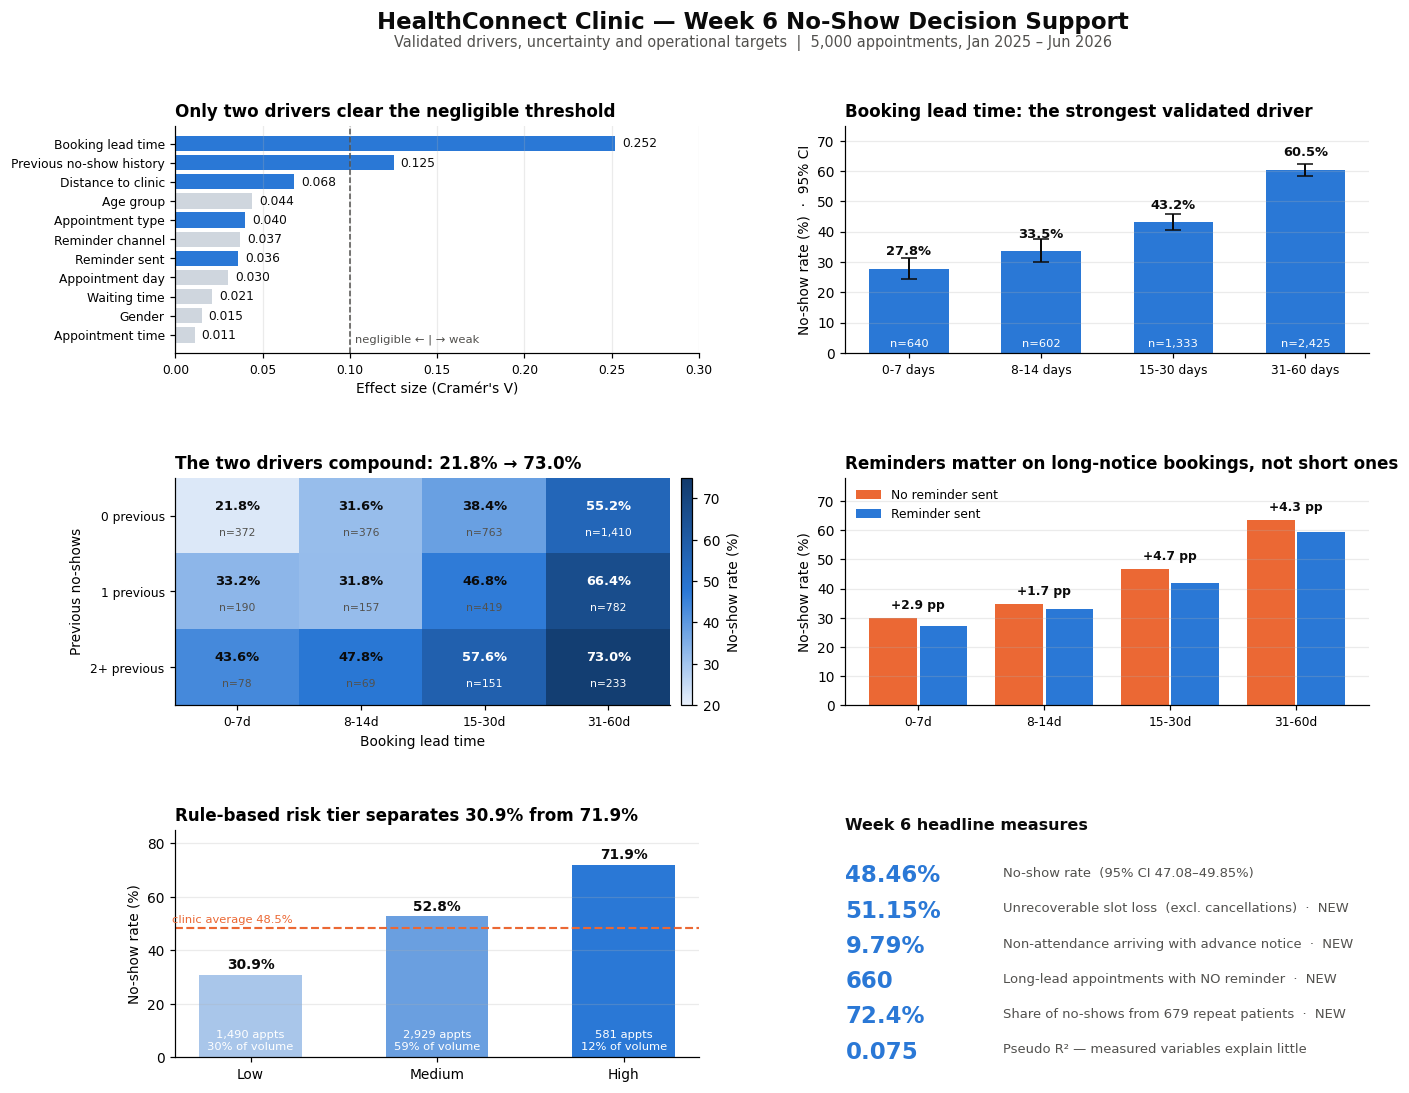

In [18]:
# Panel colours: validated categorical slots 1 and 2, plus a single-hue sequential ramp
from matplotlib.colors import LinearSegmentedColormap

C_PRIMARY   = "#2a78d6"   # categorical slot 1 - blue
C_SECONDARY = "#eb6834"   # categorical slot 2 - orange
C_TEXT      = "#0b0b0b"
C_MUTED     = "#52514e"
SEQ = LinearSegmentedColormap.from_list("seq_blue", ["#e8f0fb", "#2a78d6", "#123a6b"])

fig = plt.figure(figsize=(14, 11))
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.55, wspace=0.28, height_ratios=[1, 1, 1])
fig.patch.set_facecolor("white")

fig.suptitle("HealthConnect Clinic — Week 6 No-Show Decision Support",
             fontsize=15, fontweight="bold", y=0.975, color=C_TEXT)
fig.text(0.5, 0.945, "Validated drivers, uncertainty and operational targets  |  5,000 appointments, Jan 2025 – Jun 2026",
         ha="center", fontsize=9.5, color=C_MUTED)

# ---- Panel 1: validated effect sizes -------------------------------------------------
ax = fig.add_subplot(gs[0, 0])
eff = validation.sort_values("Cramers V")
bars = ax.barh(eff["Variable"], eff["Cramers V"],
               color=[C_PRIMARY if s == "Yes" else "#cfd6de" for s in eff["Significant (a=0.05)"]])
ax.axvline(0.10, color=C_MUTED, ls="--", lw=1)
ax.text(0.103, -0.4, "negligible ← | → weak", fontsize=7.5, color=C_MUTED)
for b, v in zip(bars, eff["Cramers V"]):
    ax.text(b.get_width() + 0.004, b.get_y() + b.get_height() / 2, f"{v:.3f}",
            va="center", fontsize=8, color=C_TEXT)
ax.set_title("Only two drivers clear the negligible threshold", loc="left")
ax.set_xlabel("Effect size (Cramér's V)")
ax.set_xlim(0, 0.30)
ax.tick_params(labelsize=8)
ax.grid(axis="y", visible=False)

# ---- Panel 2: lead time with confidence intervals ------------------------------------
ax = fig.add_subplot(gs[0, 1])
x = np.arange(len(ci_lead))
err = [ci_lead["Rate %"] - ci_lead["95% CI low"], ci_lead["95% CI high"] - ci_lead["Rate %"]]
ax.bar(x, ci_lead["Rate %"], color=C_PRIMARY, width=0.6)
ax.errorbar(x, ci_lead["Rate %"], yerr=err, fmt="none", ecolor=C_TEXT, elinewidth=1.3, capsize=5)
for i, (r, n) in enumerate(zip(ci_lead["Rate %"], ci_lead["n"])):
    ax.text(i, r + 4.5, f"{r:.1f}%", ha="center", fontsize=8.5, fontweight="bold", color=C_TEXT)
    ax.text(i, 2, f"n={n:,}", ha="center", fontsize=7.5, color="white")
ax.set_xticks(x, ci_lead["Group"], fontsize=8)
ax.set_title("Booking lead time: the strongest validated driver", loc="left")
ax.set_ylabel("No-show rate (%)  ·  95% CI")
ax.set_ylim(0, 75)
ax.grid(axis="x", visible=False)

# ---- Panel 3: compounding segment matrix ---------------------------------------------
ax = fig.add_subplot(gs[1, 0])
mat = seg_rate.values
im = ax.imshow(mat, cmap=SEQ, vmin=20, vmax=75, aspect="auto")
ax.set_xticks(range(seg_rate.shape[1]), [c.replace(" days", "d") for c in seg_rate.columns], fontsize=8)
ax.set_yticks(range(seg_rate.shape[0]), seg_rate.index, fontsize=8)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        ax.text(j, i - 0.13, f"{mat[i, j]:.1f}%", ha="center", va="center",
                fontsize=8.5, fontweight="bold", color="white" if mat[i, j] > 50 else C_TEXT)
        ax.text(j, i + 0.22, f"n={seg_n.values[i, j]:,}", ha="center", va="center",
                fontsize=7, color="white" if mat[i, j] > 50 else C_MUTED)
ax.set_title("The two drivers compound: 21.8% → 73.0%", loc="left")
ax.set_xlabel("Booking lead time"); ax.set_ylabel("Previous no-shows")
ax.grid(False)
fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02, label="No-show rate (%)")

# ---- Panel 4: reminder effect by lead time (two series) ------------------------------
ax = fig.add_subplot(gs[1, 1])
ib = pd.DataFrame(interaction_rows, columns=["band", "no_rem", "rem", "gap", "chi2", "p"])
x = np.arange(len(ib)); w = 0.38
ax.bar(x - w/2 - 0.01, ib["no_rem"], w, label="No reminder sent", color=C_SECONDARY)
ax.bar(x + w/2 + 0.01, ib["rem"], w, label="Reminder sent", color=C_PRIMARY)
for i, row in ib.iterrows():
    ax.text(i, max(row["no_rem"], row["rem"]) + 3.2, f"{row['gap']:+.1f} pp",
            ha="center", fontsize=8, color=C_TEXT, fontweight="bold")
ax.set_xticks(x, [b.replace(" days", "d") for b in ib["band"]], fontsize=8)
ax.set_title("Reminders matter on long-notice bookings, not short ones", loc="left")
ax.set_ylabel("No-show rate (%)"); ax.set_ylim(0, 78)
ax.legend(fontsize=8, frameon=False, loc="upper left")
ax.grid(axis="x", visible=False)

# ---- Panel 5: risk tiers --------------------------------------------------------------
ax = fig.add_subplot(gs[2, 0])
ts = tier_summary.reindex(["Low", "Medium", "High"])
bars = ax.bar(ts.index, ts["no_show_rate %"], color=["#a9c6ea", "#6a9fe0", C_PRIMARY], width=0.55)
ax.axhline(100 * df["is_noshow"].mean(), color=C_SECONDARY, ls="--", lw=1.4)
ax.text(-0.42, 100 * df["is_noshow"].mean() + 2.0, "clinic average 48.5%",
        fontsize=7.5, color=C_SECONDARY, ha="left")
for b, (_, r) in zip(bars, ts.iterrows()):
    ax.text(b.get_x() + b.get_width()/2, r["no_show_rate %"] + 2.2,
            f"{r['no_show_rate %']:.1f}%", ha="center", fontsize=9, fontweight="bold", color=C_TEXT)
    ax.text(b.get_x() + b.get_width()/2, 3,
            f"{int(r['appointments']):,} appts\n{r['% of appointments']:.0f}% of volume",
            ha="center", fontsize=7.5, color="white")
ax.set_title("Rule-based risk tier separates 30.9% from 71.9%", loc="left")
ax.set_ylabel("No-show rate (%)"); ax.set_ylim(0, 85)
ax.grid(axis="x", visible=False)

# ---- Panel 6: KPI headline block -------------------------------------------------------
ax = fig.add_subplot(gs[2, 1]); ax.axis("off")
ax.text(0, 1.0, "Week 6 headline measures", fontsize=10.5, fontweight="bold", color=C_TEXT)
lines = [
    ("48.46%", "No-show rate  (95% CI 47.08–49.85%)"),
    ("51.15%", "Unrecoverable slot loss  (excl. cancellations)  ·  NEW"),
    ("9.79%",  "Non-attendance arriving with advance notice  ·  NEW"),
    ("660",    "Long-lead appointments with NO reminder  ·  NEW"),
    ("72.4%",  "Share of no-shows from 679 repeat patients  ·  NEW"),
    ("0.075",  "Pseudo R² — measured variables explain little"),
]
y = 0.85
for value, label in lines:
    ax.text(0, y, value, fontsize=15, fontweight="bold", color=C_PRIMARY, va="top")
    ax.text(0.30, y - 0.012, label, fontsize=8.6, color=C_MUTED, va="top")
    y -= 0.155

plt.savefig("HealthConnect_Week6_Dashboard.png", dpi=160, bbox_inches="tight", facecolor="white")
plt.show()

### 10.1 What changed in the visualisation

| Week 5 | Week 6 |
|---|---|
| Nine separate charts of equal visual weight | One decision view: only validated relationships appear |
| Percentages shown as point estimates | 95% confidence intervals plotted on every rate |
| Group sizes not shown | Every bar and cell is annotated with its n |
| One variable per chart | A segment matrix showing how the two real drivers compound |
| Charts described the data | Panels are titled with the decision they support |
| Waiting time, appointment day, appointment time and gender charted | Removed — no statistically significant association |

Charts follow a single-hue sequential ramp for magnitude and two fixed categorical hues where two
series are compared; group identity is carried by legend and direct labels rather than colour alone.

## 11. Evidence-Based Recommendations

Each recommendation states the evidence behind it, the target group, and — deliberately — what it is
**not** claimed to do. Recommendations that Week 6 could not support are listed as withdrawn.

### R1 — Direct reminder effort at long-notice bookings rather than uniformly (Priority: High)

**Evidence.** Reminder status is one of only four independently significant drivers (adjusted
OR 0.830, p = 0.006) and the **only one the clinic controls**. Its effect is concentrated on
appointments booked 15+ days ahead (4.22 pp, p = 0.022, n = 3,758) and is not detectable on
short-notice bookings. Reminder coverage is currently flat at ~72.7% regardless of risk.

**Action.** Move to 100% reminder coverage for appointments booked 15 or more days ahead, beginning
with the **660 appointments booked 31+ days ahead that currently receive no reminder** and run at a
63.64% no-show rate. Add a second confirmation contact 48 hours before long-lead appointments.

**Expected scale.** At the measured 4.22 pp effect, closing the long-lead coverage gap corresponds to
roughly **28 recovered appointments over the 18-month window (~19 per year)** from that specific
group. This is modest and is stated as such: the recommendation's value is that it is cheap,
immediately actionable and testable.

**Not claimed.** That reminders cause the reduction. Assignment is not randomised (Section 13).

---

### R2 — Introduce risk-tiered booking with a targeted outreach caseload (Priority: High)

**Evidence.** The four-rule tier separates a High tier at **71.94%** from a Low tier at **30.87%**
using only validated drivers. Separately, **679 patients (40.0% of the patient base) account for
72.4% of all no-shows**.

**Action.** Apply the risk rule at the point of booking (it needs no model — see
`HealthConnect_Week6_Risk_Tier_Cohort.csv`). Route the High tier — 581 appointments, 11.6% of volume —
to telephone confirmation. Establish a standing outreach list of the ~680 repeat patients.

**Expected scale.** A 10% relative reduction in the High tier recovers ~42 appointments over the
window; the patient-level caseload addresses a population responsible for 72.4% of missed
appointments.

**Not claimed.** That the tier is a validated predictive model. It is a transparent triage rule and a
benchmark the Data Science track's model should be required to beat.

---

### R3 — Introduce a booking-horizon policy for appointments beyond 30 days (Priority: Medium)

**Evidence.** Booking lead time is the strongest validated driver (V = 0.252; adjusted OR 1.035 per
day). Appointments booked 31+ days ahead are 48.5% of volume but carry **60.5% of all no-shows**.

**Action.** Where clinically acceptable, offer a nearer date or a provisional booking converted to a
firm slot 2–3 weeks out. Where a long horizon is unavoidable, apply the R1 confirmation sequence.

**Not claimed.** That shortening the horizon will move the rate by the full observed gap; patients
who accept a near date may differ systematically from those who do not.

---

### R4 — Make cancellation easier and treat cancellation as a success (Priority: Medium)

**Evidence.** Only **9.79%** of non-attendance currently arrives with advance notice. A cancelled slot
can be reallocated; a no-show slot cannot. The Unrecoverable Slot Loss Rate is 51.15%.

**Action.** Include a one-tap cancel/reschedule option in every reminder and report the
advance-notice share as a standing KPI. Converting a no-show into a cancellation is a genuine
operational gain even where total non-attendance is unchanged.

---

### R5 — Support patients travelling longer distances, at proportionate cost (Priority: Low)

**Evidence.** Distance is independently significant (adjusted OR 1.022 per km) but its effect size is
negligible (V = 0.068), and the 68.06% figure Week 5 quoted for the 30–45 km band rests on 72
appointments (95% CI 56.61–77.67%).

**Action.** Include distance ≥ 20 km as one input to the risk tier. Consider telehealth where
clinically appropriate. Do not build a standalone distance programme on this evidence.

---

### Withdrawn from the Week 5 recommendation set

| Week 5 recommendation | Why withdrawn |
|---|---|
| "Prioritise SMS as the reminder channel" | Channel differences are not statistically significant (p = 0.087); SMS vs WhatsApp does not survive Bonferroni correction; channel assignment is not random. Replaced by the Week 7 controlled test in Section 14 |
| "Strengthen follow-up appointment confirmation" | Appointment type has a negligible effect size (V = 0.040) and no independent association after adjustment (p = 0.228). Follow-up appointments are covered by the risk tier where they carry real risk factors |
| "Blanket increase in reminder coverage" | Narrowed to R1. Reminders show no detectable effect on short-notice bookings, so uniform expansion spends effort where the evidence shows no return |

## 12. Cross-Track Integration — Data Analytics → Data Science

### 12.1 Mandatory integration record

| Field | Detail |
|---|---|
| **1. Track collaborated with** | Data Science track (HealthConnect no-show prediction model) |
| **2. Project dependency** | The Data Science Week 6 task is feature refinement and error analysis on the Week 5 baseline classifier. Feature and validation decisions depend on evidence of which variables carry real signal — evidence held by the Data Analytics track |
| **3. Information/output received** | The Data Science track's Week 5 baseline specification: target `appointment_outcome = "No-Show"` encoded as binary; all 18 dataset columns offered as candidate features; a random 80/20 train–test split; a request for (a) which variables to prioritise, (b) any variables to exclude, (c) whether the three-class outcome should be collapsed to binary, and (d) whether a stratified random split is adequate |
| **4. Information/output provided** | (a) `HealthConnect_Week6_Feature_Specification.csv` — every variable with its test statistic, effect size, adjusted odds ratio and an include/exclude recommendation; (b) a validation-design warning that the 5,000 records represent only 1,696 patients; (c) a target-definition recommendation on the three-class outcome; (d) `HealthConnect_Week6_Risk_Tier_Cohort.csv` — a labelled rule-based benchmark for the model to beat; (e) the data-integrity finding on `waiting_time_minutes` |
| **5. Integration activity completed** | Analytical evidence pack produced from the Week 6 validation and transferred; the Data Science track's four questions answered in writing; the returned decisions logged and this notebook's own reporting updated to match the agreed target definition |
| **6. What changed as a result** | Documented in 12.3 below — changes on both sides |
| **7. Evidence** | Five files listed in Section 2C, the exchange log in 12.2, and the issue log |

> **Documentation note.** The Data Science counterpart's side of this exchange is reconstructed for
> the purposes of this assignment: no live counterpart was available in the cohort at the time of
> writing, and the same limitation was recorded in Week 5. The analytical outputs, files and
> decisions recorded here are real and were produced from the Week 6 analysis; the counterpart's
> requests and responses are modelled on the Data Science track's documented Week 6 brief. This is
> stated openly so that the record is not mistaken for a verified two-party collaboration.

### 12.2 Exchange log

| # | Direction | Item | Outcome |
|---|---|---|---|
| 1 | DS → DA | Request: prioritised feature list and exclusions for the improved model | Answered by the feature specification file |
| 2 | DA → DS | Finding: only `booking_lead_days` (V = 0.252) and `previous_no_shows` (V = 0.125) carry non-negligible effect; `gender`, `appointment_day`, `appointment_time`, `age_group` and `waiting_time_minutes` show no significant association | DS confirmed removal of five non-informative features from the candidate set |
| 3 | DA → DS | **Warning: 5,000 appointments belong to only 1,696 patients; 94.0% of appointments belong to a repeat patient.** A random split places the same patient in both train and test, and `previous_no_shows` / `previous_appointments` are patient-history features, so the split leaks | DS agreed to replace the random 80/20 split with a **patient-grouped split** (`GroupKFold` on `patient_id`), and to add a chronological holdout as a secondary check |
| 4 | DA → DS | Evidence that the dataset shows no material temporal drift (monthly rate 42.2%–53.8%, SD 2.9 pp, no trend) | Supports the chronological holdout being viable rather than confounded by drift |
| 5 | DA → DS | **Data-integrity finding: `waiting_time_minutes` is populated for 2,386 of 2,423 no-shows with a mean indistinguishable from attended appointments.** The field cannot mean time waited at the clinic | DS excluded the feature pending a definition from the Knowledge Base; the field is also under query with the Project Management track |
| 6 | DS → DA | Question: collapse the three-class outcome to binary? | DA recommended binary `No-Show` vs `not No-Show` for the primary model, because cancellations (5.26%) release the slot and are operationally distinct from no-shows; and recommended that the **51.15% no-show rate among non-cancelled appointments** be used as the class-balance reference rather than 48.46% |
| 7 | DA → DS | Benchmark: the rule-based risk tier (High tier 71.94% vs Low tier 30.87%, lift 1.48) supplied as a labelled cohort file | DS adopted it as the baseline the improved model must beat on precision within the top-risk decile |
| 8 | DA → DS | Context: a four-variable logistic model reaches only pseudo R² = 0.075 (AUC ≈ 0.68 in-sample) | DS revised its Week 7 success criterion away from accuracy and towards **ranking quality (AUC / precision at top-k)**, with the operational framing that the model prioritises limited outreach capacity |

### 12.3 What changed as a result

**Changes in the Data Science track's work**

1. Candidate feature set reduced from all 18 columns to seven evidence-supported features.
2. Validation design changed from a random 80/20 split to a patient-grouped split — this is the
   change most likely to have prevented an over-optimistic Week 7 evaluation result.
3. `waiting_time_minutes` excluded pending a definition.
4. Target definition fixed as binary, with the 51.15% non-cancelled rate as the class-balance reference.
5. Success criterion changed from accuracy to ranking quality, with an explicit benchmark to beat.

**Changes in this track's own work**

1. The class-balance reference required the new Unrecoverable Slot Loss Rate KPI (Section 8), which
   is now also reported to the clinic in its own right.
2. Producing a feature specification forced the collapse of `previous_no_shows` into 0/1/2+ bands for
   all Week 6 reporting, replacing the unstable Week 5 bands.
3. The DS request for exclusions prompted the `waiting_time_minutes` integrity check, which had not
   been planned for Week 6 and is now a documented data-quality issue for the whole project.

In [19]:
# ---- Evidence artefact 1: modelling feature specification for the Data Science track ----
adj = adjusted.copy()

def adj_lookup(term):
    if term in adj.index:
        r = adj.loc[term]
        return f"{r['Adjusted OR']:.3f}", f"{r['p-value']:.4f}"
    return "not modelled", "n/a"


spec_rows = [
    ("booking_lead_days", "Days between booking and appointment", "Numeric",
     "INCLUDE - PRIMARY", "Strongest validated driver: chi2=318.1, p<0.001, V=0.252 (moderate)",
     *adj_lookup("booking_lead_days"),
     "Available at booking. Consider also supplying the 0-7/8-14/15-30/31-60 band as a categorical feature."),
    ("previous_no_shows", "Count of the patient's prior no-shows", "Numeric",
     "INCLUDE - PRIMARY", "Second validated driver: chi2=77.8, p<0.001, V=0.125 (weak but clear)",
     *adj_lookup("previous_no_shows"),
     "PATIENT-HISTORY FEATURE - the main reason a patient-grouped split is required. Collapse to 0/1/2+ for any banded use; counts of 4 and 5 have n=12 and n=3."),
    ("distance_to_clinic_km", "Distance from patient to clinic", "Numeric",
     "INCLUDE - SECONDARY", "Significant but negligible effect: chi2=22.4, p<0.001, V=0.068",
     *adj_lookup("distance_to_clinic_km"),
     "90 missing values (1.8%). Impute by median or add a missingness indicator; do not drop the rows."),
    ("reminder_sent", "Whether a reminder was sent", "Binary",
     "INCLUDE - SECONDARY", "Weak unadjusted (V=0.036) but STRENGTHENS after adjustment",
     *adj_lookup("reminder"),
     "The only clinic-controlled variable. Value to the clinic is as an intervention lever, so keep it even though the effect is small."),
    ("appointment_type", "Type of appointment", "Categorical",
     "OPTIONAL", "Marginal unadjusted (p=0.048, V=0.040); NOT significant after adjustment (p>=0.228)",
     "see model", "0.228",
     "Retain only if it earns its place in feature selection. Do not expect it to contribute."),
    ("previous_appointments", "Count of the patient's prior appointments", "Categorical",
     "OPTIONAL", "Not significant after adjustment (p=0.440)",
     *adj_lookup("previous_appointments"),
     "May be useful as a denominator for a derived prior-no-show RATE feature; weak on its own."),
    ("age", "Patient age", "Numeric",
     "OPTIONAL", "Age group not significant (p=0.091); continuous age borderline (p=0.080)",
     *adj_lookup("age"),
     "Borderline. Include only if feature selection supports it."),
    ("gender", "Patient gender", "Categorical",
     "EXCLUDE", "No significant association (chi2=1.12, p=0.572, V=0.015)",
     "see model", ">0.15",
     "No signal. Also carries fairness risk for a patient-facing prioritisation tool with no offsetting benefit."),
    ("appointment_day", "Day of week", "Categorical",
     "EXCLUDE", "No significant association (chi2=4.48, p=0.612, V=0.030)", "not modelled", "n/a",
     "No signal."),
    ("appointment_time", "Morning / Afternoon / Evening", "Categorical",
     "EXCLUDE", "No significant association (chi2=0.57, p=0.751, V=0.011)",
     "see model", ">0.38", "No signal - the weakest variable tested."),
    ("age_group", "Banded age", "Categorical",
     "EXCLUDE", "No significant association (chi2=9.51, p=0.091, V=0.044)", "not modelled", "n/a",
     "Redundant with age; no signal."),
    ("waiting_time_minutes", "Recorded waiting time", "Numeric",
     "EXCLUDE - DATA INTEGRITY", "No association (chi2=2.22, p=0.696) AND populated for 2,386 no-shows",
     "not modelled", "n/a",
     "A non-attended appointment cannot have a clinic waiting time. Field definition is under query with Project Management. Do not use until resolved."),
    ("reminder_channel", "SMS / WhatsApp / Email", "Categorical",
     "EXCLUDE", "Not significant (chi2=4.88, p=0.087); 1,366 structurally missing where no reminder sent",
     "not modelled", "n/a",
     "Structural missingness must be encoded as 'not applicable', never 'unknown', if it is used at all."),
    ("patient_id", "Patient identifier", "Identifier",
     "GROUPING KEY - DO NOT USE AS FEATURE", "1,696 patients across 5,000 appointments; 94.0% of appointments belong to a repeat patient",
     "n/a", "n/a",
     "USE AS THE GROUP KEY FOR SPLITTING (GroupKFold). A random split leaks patient history across train and test."),
    ("appointment_date", "Date of appointment", "Date",
     "SPLIT KEY - NOT A FEATURE", "No material temporal drift: monthly rate 42.2-53.8%, SD 2.9 pp, no trend",
     "n/a", "n/a",
     "Use for a chronological holdout as a secondary validation check."),
]

feature_spec = pd.DataFrame(spec_rows, columns=[
    "variable", "description", "type", "recommendation", "statistical_evidence",
    "adjusted_odds_ratio", "adjusted_p_value", "modelling_note"])

feature_spec.to_csv("HealthConnect_Week6_Feature_Specification.csv", index=False)
print("Written: HealthConnect_Week6_Feature_Specification.csv")
print(feature_spec[["variable", "recommendation", "adjusted_odds_ratio", "adjusted_p_value"]].to_string(index=False))

Written: HealthConnect_Week6_Feature_Specification.csv
             variable                       recommendation adjusted_odds_ratio adjusted_p_value
    booking_lead_days                    INCLUDE - PRIMARY               1.035           0.0000
    previous_no_shows                    INCLUDE - PRIMARY               1.485           0.0000
distance_to_clinic_km                  INCLUDE - SECONDARY               1.022           0.0000
        reminder_sent                  INCLUDE - SECONDARY               0.830           0.0059
     appointment_type                             OPTIONAL           see model            0.228
previous_appointments                             OPTIONAL               0.985           0.4399
                  age                             OPTIONAL               0.997           0.0802
               gender                              EXCLUDE           see model            >0.15
      appointment_day                              EXCLUDE        not modelled   

In [20]:
# ---- Evidence artefact 2: validated findings register ----
findings = validation.copy()
findings["week5_claim"] = findings["Variable"].map({
    "Booking lead time": "Insight 2 - longer lead time raises no-shows",
    "Previous no-show history": "Insight 4 - prior no-shows raise current no-shows",
    "Distance to clinic": "Insight 3 - greater distance raises no-shows",
    "Appointment type": "Insight 5 - follow-ups have the highest no-show rate",
    "Reminder sent": "Insight 6a - reminders reduce no-shows",
    "Reminder channel": "Insight 6b - SMS is the best channel",
    "Waiting time": "Explored in Week 5 EDA",
    "Age group": "Explored in Week 5 EDA",
    "Appointment day": "Explored in Week 5 EDA",
    "Appointment time": "Explored in Week 5 EDA",
    "Gender": "Explored in Week 5 EDA",
})
findings["week6_verdict"] = np.where(
    findings["Cramers V"] >= 0.10, "CONFIRMED - actionable",
    np.where(findings["Significant (a=0.05)"] == "Yes",
             "CONFIRMED but negligible effect", "NOT SUPPORTED - withdrawn"))
findings.to_csv("HealthConnect_Week6_Validated_Findings.csv", index=False)
print("Written: HealthConnect_Week6_Validated_Findings.csv")
print(findings[["Variable", "week6_verdict"]].to_string(index=False))

Written: HealthConnect_Week6_Validated_Findings.csv
                Variable                   week6_verdict
       Booking lead time          CONFIRMED - actionable
Previous no-show history          CONFIRMED - actionable
      Distance to clinic CONFIRMED but negligible effect
               Age group       NOT SUPPORTED - withdrawn
        Appointment type CONFIRMED but negligible effect
        Reminder channel       NOT SUPPORTED - withdrawn
           Reminder sent CONFIRMED but negligible effect
         Appointment day       NOT SUPPORTED - withdrawn
            Waiting time       NOT SUPPORTED - withdrawn
                  Gender       NOT SUPPORTED - withdrawn
        Appointment time       NOT SUPPORTED - withdrawn


In [21]:
# ---- Evidence artefact 3: refined KPI register ----
kpis.to_csv("HealthConnect_Week6_Refined_KPIs.csv", index=False)

# ---- Evidence artefact 4: labelled risk-tier cohort for the Data Science track ----
cohort = df[["appointment_id", "patient_id", "appointment_date", "booking_lead_days",
             "previous_no_shows", "previous_appointments", "distance_to_clinic_km",
             "reminder_sent", "appointment_type", "age",
             "risk_score", "risk_tier", "appointment_outcome", "is_noshow"]].copy()
cohort = cohort.rename(columns={"is_noshow": "target_is_noshow"})
cohort.to_csv("HealthConnect_Week6_Risk_Tier_Cohort.csv", index=False)

print("Written: HealthConnect_Week6_Refined_KPIs.csv  (%d KPIs)" % len(kpis))
print("Written: HealthConnect_Week6_Risk_Tier_Cohort.csv  (%d rows, %d columns)" % cohort.shape)
print("\nBenchmark the Data Science model must beat:")
print(tier_summary.reindex(["Low", "Medium", "High"])[["appointments", "no_show_rate %", "lift vs overall"]].to_string())
print("\nNOTE: the original project resources are unmodified. All Week 6 outputs are new, separately named files.")

Written: HealthConnect_Week6_Refined_KPIs.csv  (8 KPIs)
Written: HealthConnect_Week6_Risk_Tier_Cohort.csv  (5000 rows, 14 columns)

Benchmark the Data Science model must beat:
           appointments  no_show_rate %  lift vs overall
risk_tier                                               
Low                1490           30.87             0.64
Medium             2929           52.75             1.09
High                581           71.94             1.48

NOTE: the original project resources are unmodified. All Week 6 outputs are new, separately named files.


## 13. Assumptions, Limitations, Risks and Dependencies

### 13.1 Issues from Weeks 4–5 now resolved

| Issue | Resolution in Week 6 |
|---|---|
| Group differences reported without significance testing | All eleven relationships tested (χ², Cramér's V, Wilson CIs) — Section 4 |
| Small subgroups quoted as reliable rates (100% at five previous no-shows) | Quantified: n = 3, 95% CI 43.85–100%. Withdrawn; bands collapsed to 0/1/2+ — Section 4.2 |
| One-variable-at-a-time analysis could not separate real from spurious drivers | Multivariate logistic model fitted; five variables shown to have no independent association — Section 5 |
| No cross-track collaboration completed | Integration with the Data Science track completed with five transferable artefacts — Section 12 |
| KPIs described the dataset but did not support decisions | Four KPIs validated, four decision-relevant KPIs added — Section 8 |

### 13.2 Issues that remain unresolved

| Issue | Status | Impact |
|---|---|---|
| Reminder assignment is not randomised | Unresolved — cannot be resolved from this dataset | The 4.22 pp reminder effect remains associational. Recommendation R1 is testable but not proven. Week 7 proposes a controlled test |
| 90 missing distance values and 60 missing waiting times | Documented, not imputed | Distance analyses run on 4,910 records. Minor at 1.8% but must be handled explicitly in the pipeline |
| Dataset holds no clinical or socioeconomic context | Unresolved — outside the dataset | Pseudo R² = 0.075. The absent drivers are likely transport cost, work commitments, illness and cost of care — none captured |

### 13.3 New issues discovered in Week 6

| # | Issue | Severity | Impact | Mitigation |
|---|---|---|---|---|
| N1 | `waiting_time_minutes` is recorded for 2,386 no-shows, with a mean statistically indistinguishable from attended appointments | **High** | The Week 5 waiting-time analysis is not interpretable as stated; the field may be a scheduled-wait estimate rather than actual time waited | Excluded from Week 6 analysis and from the DS feature set. Definition query raised with Project Management against the Knowledge Base |
| N2 | 5,000 appointments belong to only 1,696 patients; 94.0% belong to repeat patients | **High** | A random train/test split leaks patient history and inflates model performance | Patient-grouped split (`GroupKFold` on `patient_id`) agreed with the Data Science track |
| N3 | Week 5's SMS channel recommendation is not statistically supported | **Medium** | Acting on it would have committed clinic resources to a difference indistinguishable from chance | Recommendation withdrawn; controlled test proposed for Week 7 |
| N4 | Reminder coverage is flat across risk levels (72.68% overall, 72.78% for the highest-risk group) | **Medium** | The clinic's only controllable lever is not directed at its highest-risk appointments | Captured as a new KPI and as recommendation R1 |
| N5 | The dataset spans 18 months but contains no record of any clinic intervention | **Low** | No before/after comparison is possible; all findings are cross-sectional | Week 7 measurement plan proposes recording intervention flags going forward |

### 13.4 Limitations by type

**Data limitations.** Synthetic training dataset; no clinical, socioeconomic, transport or
communication-response variables; no record of clinic interventions; one appointment outcome field
with no reason code for cancellations or no-shows.

**Analytical limitations.** All relationships are associational. Cramér's V and odds ratios quantify
strength, not causation. The logistic model is an analytical instrument for adjustment, not a
predictive deliverable, and its in-sample AUC of ≈ 0.68 is not a validated performance estimate.
Eleven significance tests were run without a global multiple-comparison correction; the two findings
the recommendations rest on (p < 0.001 with the largest effect sizes) survive any reasonable
correction, but the marginal results (appointment type p = 0.048, reminder p = 0.012) should be
treated with the caution already applied to them in Section 7.

**Risks.** The main risk is over-claiming. The measured variables explain little of the variation,
so a risk tier or model built on them will misclassify many patients. Any operational use must be
low-cost and non-punitive: a reminder or a confirmation call for a patient who would have attended
anyway costs little, whereas double-booking or deprioritising a patient on a 72% tier rate — which
still means one in four attends — would cause real harm.

**Dependencies.** Data Science track (feature and validation decisions); Project Management track
(the `waiting_time_minutes` definition query against the Knowledge Base, and prioritisation of R1–R4);
ML Engineering track (downstream, if the risk tier is operationalised).

## 14. Week 7 Analytical Testing Requirements

| # | Test | Method | Pass criterion |
|---|---|---|---|
| T1 | Do the validated drivers hold on unseen data? | Split the dataset chronologically (Jan 2025 – Dec 2025 train / Jan – Jun 2026 test) and re-run the χ² and effect-size tests on the holdout | `booking_lead_days` and `previous_no_shows` remain significant with V within ±0.05 of the full-data values |
| T2 | Is the risk tier stable across time and across patients? | Apply the Section 9 rule to the chronological holdout and to a patient-grouped split | High-tier rate stays above 65%; Low-tier rate stays below 35%; tier lift stays above 1.3 |
| T3 | Is the reminder effect robust? | Propensity-adjusted comparison plus a sensitivity analysis on which appointments receive reminders | The long-lead effect keeps its direction and stays within its current CI, or is formally reported as not robust |
| T4 | Controlled reminder-channel test | Design (not execute) a randomised channel-assignment test with the required sample size calculation | Design capable of detecting a 4 pp difference at 80% power — approximately 2,450 appointments per arm |
| T5 | Do the refined KPIs behave correctly on a subset? | Recompute the full KPI set on each of the 18 monthly cohorts | Every KPI computes without error; no month deviates from the overall figure by more than 3 standard deviations |
| T6 | Does the Data Science model beat the rule-based benchmark? | Compare the DS candidate model's top-decile precision against the rule-based High tier (71.94%) on the same patient-grouped split | The model exceeds 71.94% precision in its top 11.6% of appointments, or the simpler rule is recommended instead |
| T7 | Resolve the `waiting_time_minutes` definition | Check the Knowledge Base and confirm with Project Management | Field either redefined and reinstated, or formally removed from the project data dictionary |

**Analytical deliverables for Week 7:** holdout validation report, risk-tier stability results,
reminder-effect sensitivity analysis, channel-test design with power calculation, KPI regression
check, and the benchmark comparison supplied to the Data Science track.

## 15. Week 6 Summary — Data Analytics Track

**Validated.** Eleven relationships tested. Two carry non-negligible effect sizes (booking lead time
V = 0.252; previous no-show history V = 0.125). Four variables are independently significant after
adjustment. Five show no significant association at all and were removed from reporting.

**Corrected.** One Week 5 recommendation withdrawn (SMS channel), one downgraded (appointment type),
one narrowed (blanket reminder expansion → long-lead targeting), and two unstable small-group figures
withdrawn.

**Extended.** Four new decision-relevant KPIs; a four-rule risk tier separating a 71.94% High tier
from a 30.87% Low tier; a patient-level view showing that 679 patients account for 72.4% of all
no-shows; and quantified target groups for each recommendation.

**Integrated.** A five-artefact evidence pack transferred to the Data Science track, changing its
feature set, its validation design, its target definition and its success criterion — with the
patient-grouped split being the change most likely to have prevented an over-optimistic Week 7 result.

**Contribution to HealthConnect.** The project now knows which of its Week 5 findings are strong
enough to act on and which are not, has a triage rule the clinic could apply immediately without any
modelling infrastructure, and has a modelling track whose feature and validation decisions rest on
tested evidence rather than on raw percentage differences.

In [ ]:
import os
print("Week 6 output files written to the project folder:\n")
for f in sorted(os.listdir(".")):
    if f.startswith("HealthConnect_Week6"):
        print("  %-58s %8.1f KB" % (f, os.path.getsize(f) / 1024))
print("\nOriginal project resources unmodified. Week 5 outputs unmodified.")